# Tau-5* SEC-SAXS: clean-window selection, standard plots and EFA

This notebook accompanies the files in `poster_results/`. It uses the requested WT_092025 and AA_052026 HDF5 series. The original source notebooks remain unchanged. The selected windows are **WT 159–175** and **AA 169–188**, inclusive and zero indexed. See `EFA_report.md` for biological interpretation and `EFA_equations.md` for the full equation walkthrough.

No oligomeric identity is assigned from Rg alone. Window scores are a presentation-quality criterion conditional on the supplied errors and chosen residual-background correction.

In [1]:
from pathlib import Path
import sys, json, numpy as np
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'analysis'))
from run_efa import analyze, guinier
from select_windows import average, candidates
from IPython.display import display, Image, Markdown
assert (ROOT / 'BNL_SAXS/data/WT_092025.hdf5').exists()


## Verify the WT construct

Your exact supplied sequence is the experimental reference. It has 120 residues, including the N-terminal GP; the segment after GP has 118. BMRB53105 is a 119-residue Tau-5* construct. The user sequence adds GP and removes its terminal C. User W70/W106 correspond to AR W397/W433. Expected WT monomer mass is the user-supplied 12.1 kDa.

In [2]:
sequence_info = json.loads((ROOT/'background/sequence_comparison.json').read_text())
sequence_info


{'user_length': 120,
 'bmrb_length': 119,
 'relationship': 'user = GP + BMRB53105 sequence without terminal C',
 'expected_monomer_mass_kDa': 12.1,
 'sequence_1_based_W_positions': [70, 106],
 'AR_W_positions': [397, 433],
 'mapping': 'User positions 3–120 match BMRB positions 1–118 and author AR positions 330–447 of BMRB51479.',
 'source': 'https://bmrb.io/ftp/pub/bmrb/entry_directories/bmr53105/bmr53105_3.str'}

## Recompute the selected averaging windows

Candidates contain the local SEC maximum, have at least seven frames, and lie inside WT 150–195 or AA 155–215. Passing criteria: ≤5% Rg span over four low-q cutoffs, Guinier reduced weighted residual ≤1.5, and amplitude-scaled first/second-half profile residual mean square ≤1.5. Among passing candidates we maximize the mean-profile signal/error norm. Shared residual-background uncertainty is retained when averaging.

The optimization does not use a target Rg. Neighboring windows are nearly tied.

In [3]:
selection = []
for name, lo, hi in [('WT_092025',150,195), ('AA_052026',155,215)]:
    rows, best = candidates(name, lo, hi)
    selection.append(best)
    print(name, 'evaluated:',len(rows), 'selected:',best['start'],best['end'],
          'Rg:',round(best['Rg'],3), 'A', 'qmin span:',round(100*best['qmin_Rg_relative_span'],2),'%')


WT_092025 evaluated: 475 selected: 159 175 Rg: 25.791 A qmin span: 1.43 %


AA_052026 evaluated: 876 selected: 169 188 Rg: 32.346 A qmin span: 2.68 %


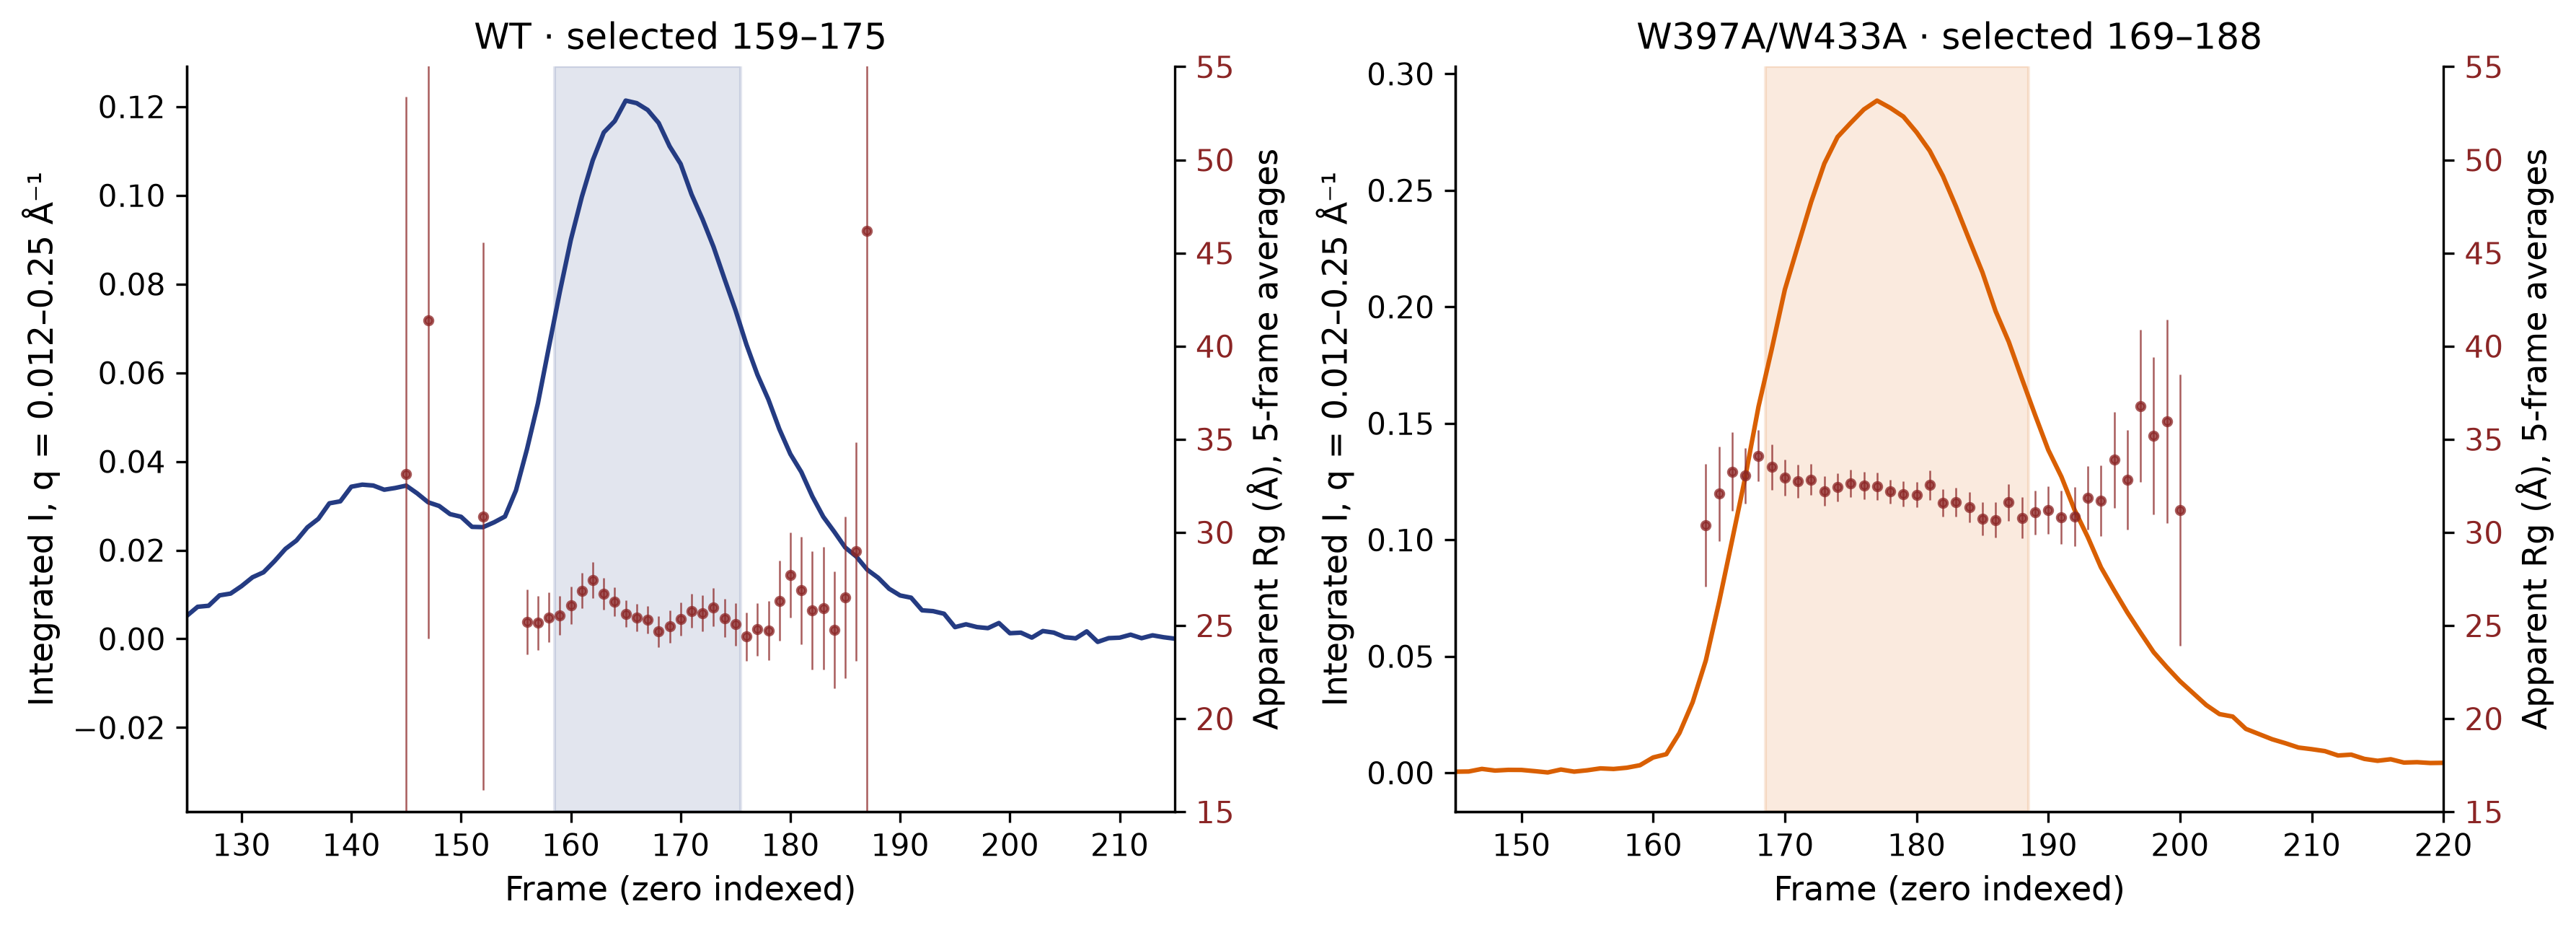

In [4]:
display(Image(filename=str(ROOT/'poster_results/SEC_selected_windows.png')))


## Arithmetic mean profiles and Guinier fits

The Guinier relation is

$$\ln I(q)=\ln I(0)-\frac{R_g^2}{3}q^2,$$

so a fitted slope m gives $R_g=\sqrt{-3m}$. The primary fit starts at q=0.012 Å⁻¹ and enforces qmax Rg≤1. Points excluded from the fitted range are gray in the plots. Fit errors are conditional and exclude background-choice systematics.

In [5]:
guinier_results = {}
for s in selection:
    q, intensity, error = average(s['sample'],s['start'],s['end'])
    fit = guinier(q,intensity,error)
    guinier_results[s['sample']] = fit
    print(s['sample'], fit)


WT_092025 {'Rg': 25.79130298737548, 'fit_se': 0.5843627653960966, 'I0': 1.6670910507471233, 'qmin': 0.012, 'qmax': 0.038, 'qRgmax': 0.9800695135202683, 'n': 27, 'chi2': 0.4983256226424583}
AA_052026 {'Rg': 32.346301385479485, 'fit_se': 0.5086195640714725, 'I0': 4.749794588648265, 'qmin': 0.012, 'qmax': 0.030000000000000002, 'qRgmax': 0.9703890415643847, 'n': 19, 'chi2': 0.4816581181110445}


### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

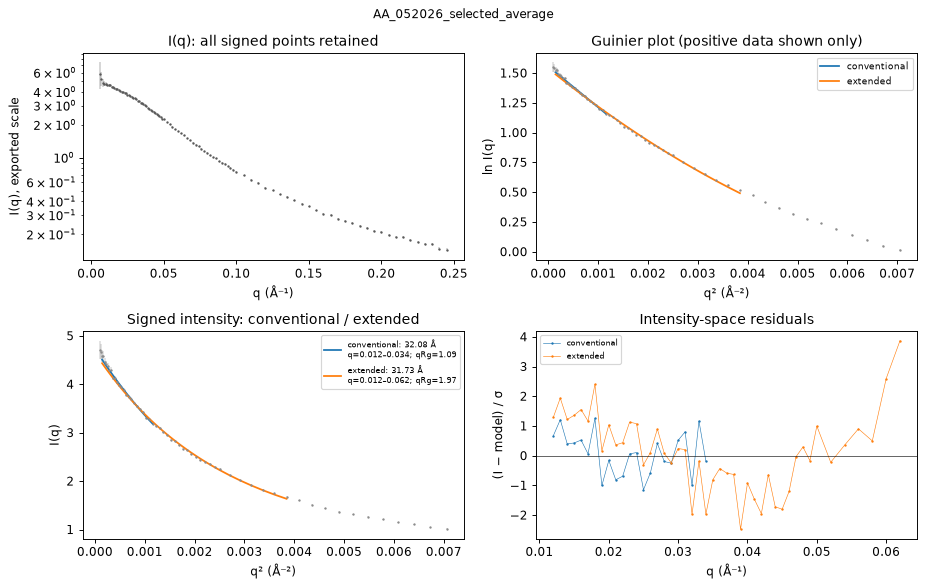

Component identity and physical validity are not established by a converged fit.

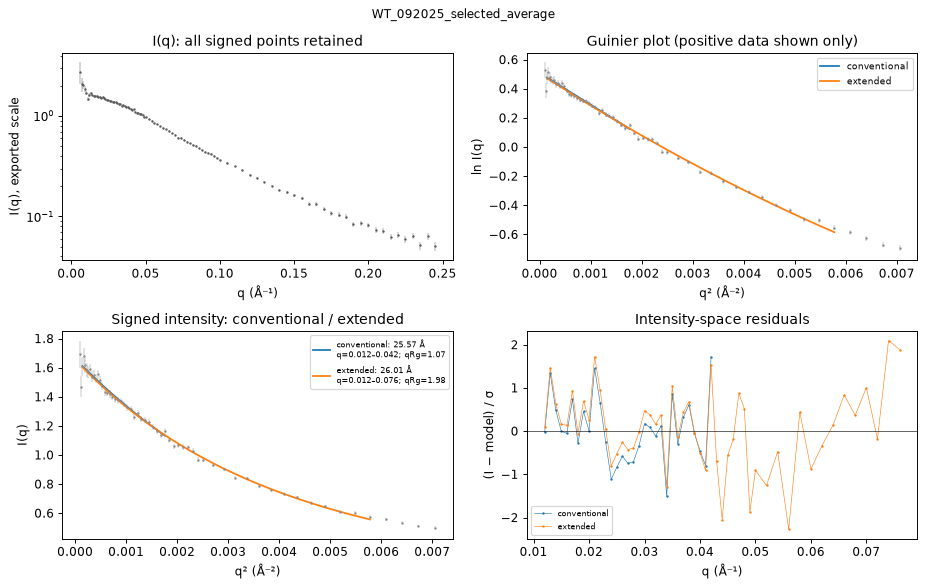

Component identity and physical validity are not established by a converged fit.

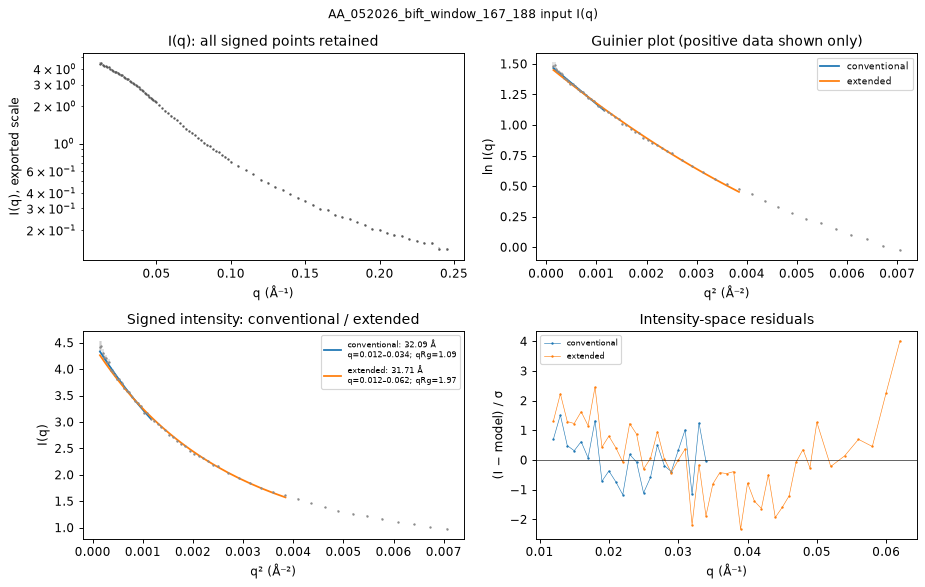

Component identity and physical validity are not established by a converged fit.

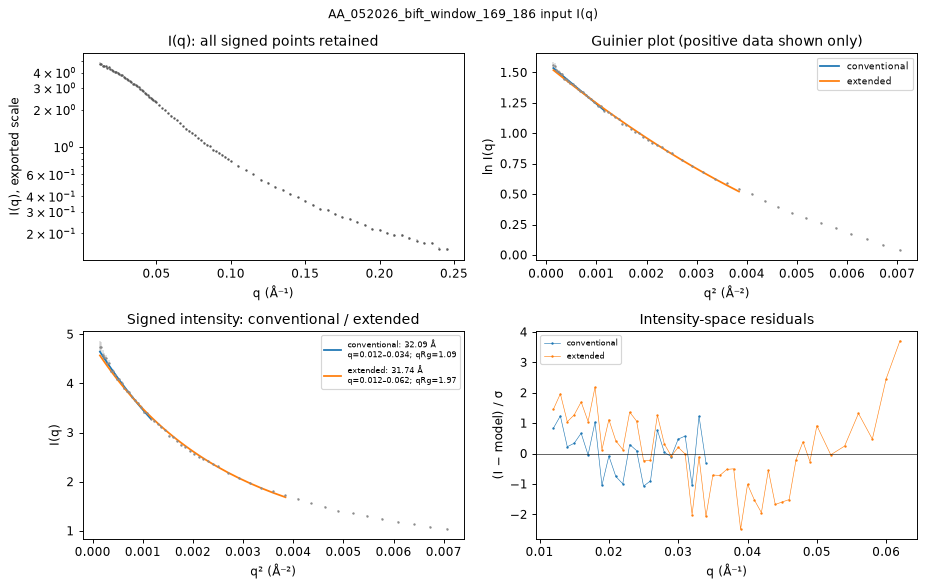

Component identity and physical validity are not established by a converged fit.

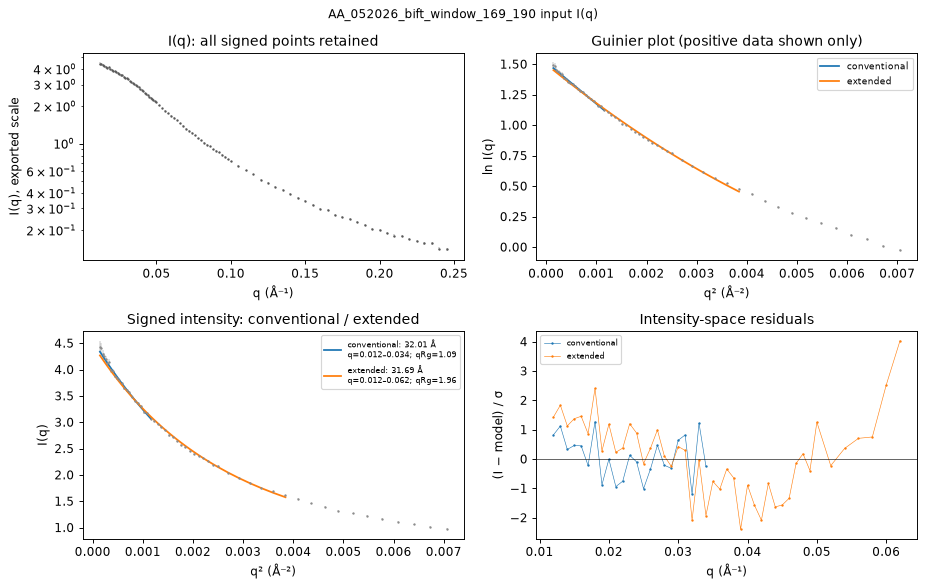

Component identity and physical validity are not established by a converged fit.

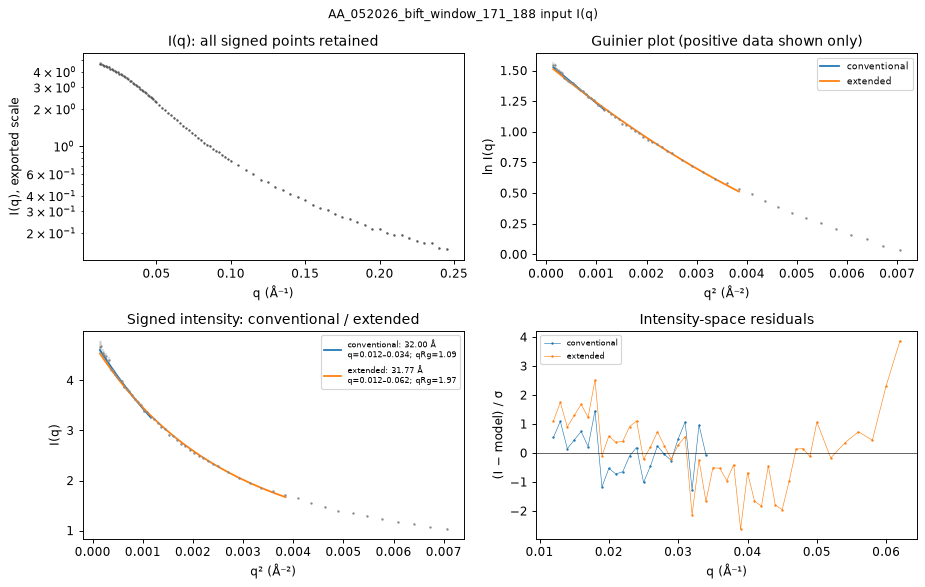

Component identity and physical validity are not established by a converged fit.

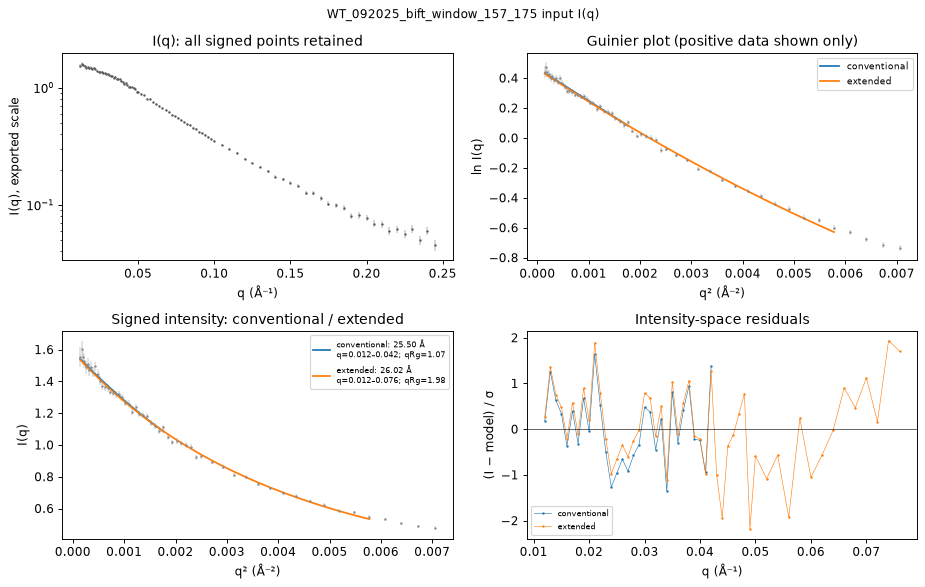

Component identity and physical validity are not established by a converged fit.

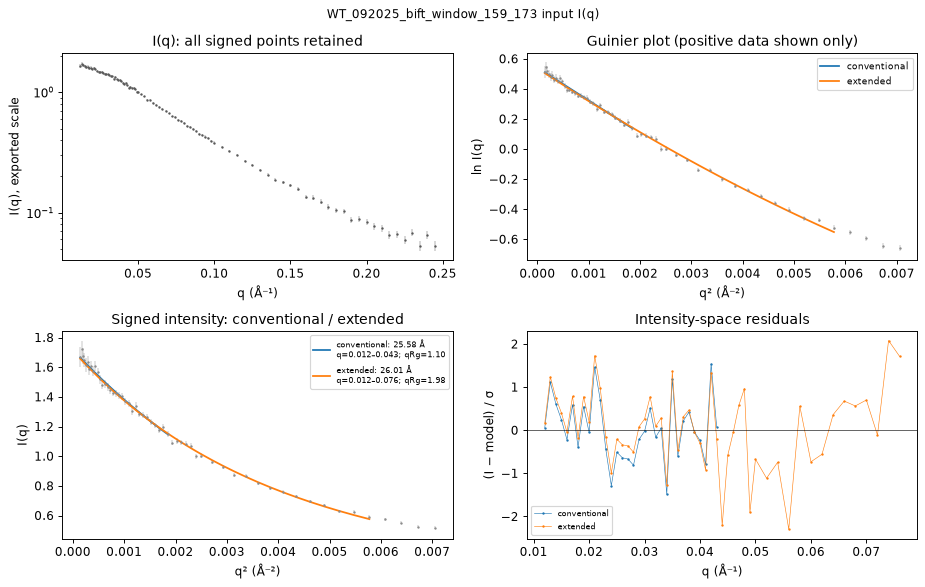

Component identity and physical validity are not established by a converged fit.

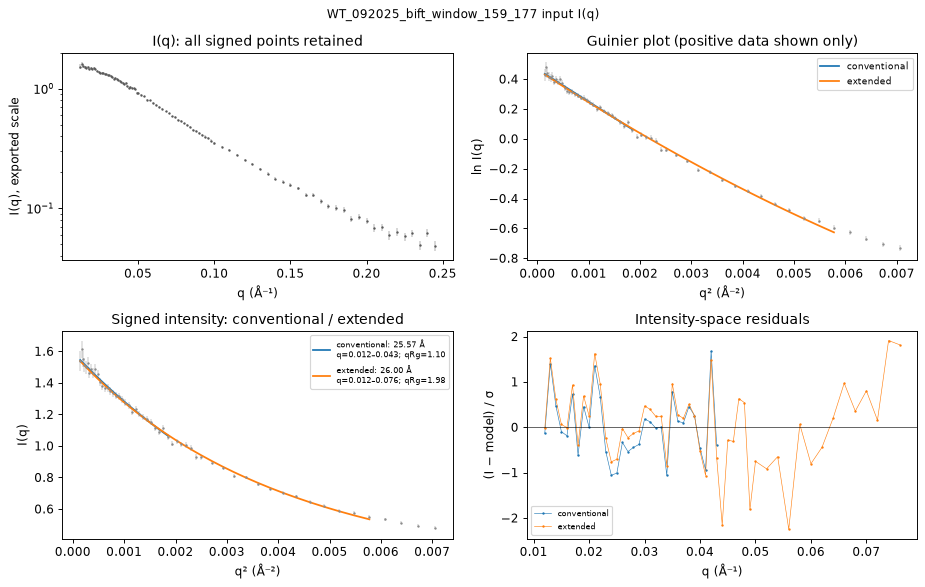

Component identity and physical validity are not established by a converged fit.

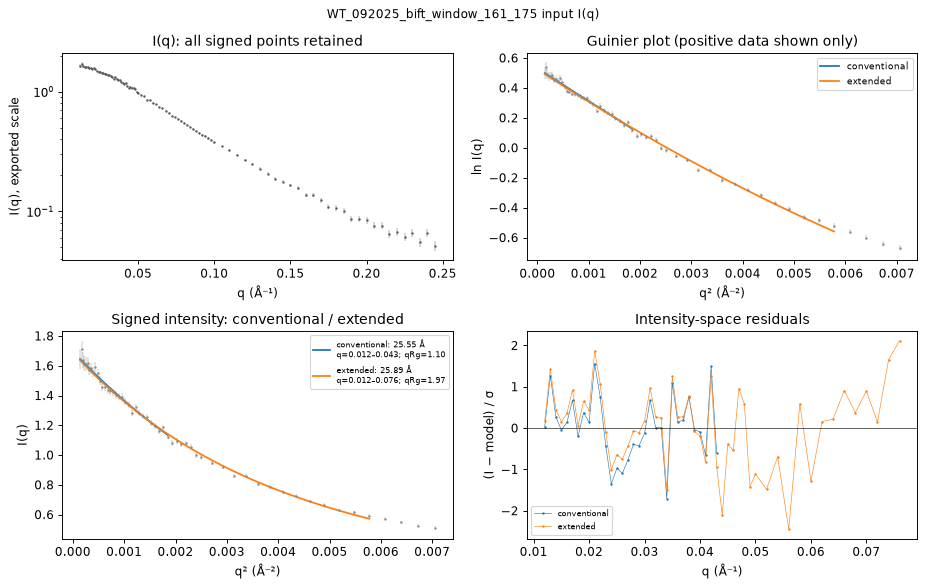

Component identity and physical validity are not established by a converged fit.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|AA_052026_selected_average|32.08 ± 0.33|33.45 ± 0.39|31.73 ± 0.10|[31.54, 31.93]|
|WT_092025_selected_average|25.57 ± 0.43|26.35 ± 0.49|26.01 ± 0.14|[25.75, 26.29]|
|AA_052026_bift_window_167_188 input I(q)|32.09 ± 0.33|33.46 ± 0.39|31.71 ± 0.10|[31.5, 31.9]|
|AA_052026_bift_window_169_186 input I(q)|32.09 ± 0.33|33.45 ± 0.39|31.74 ± 0.10|[31.53, 31.92]|
|AA_052026_bift_window_169_190 input I(q)|32.01 ± 0.33|33.36 ± 0.39|31.69 ± 0.10|[31.48, 31.88]|
|AA_052026_bift_window_171_188 input I(q)|32.00 ± 0.33|33.35 ± 0.39|31.77 ± 0.10|[31.56, 31.96]|
|WT_092025_bift_window_157_175 input I(q)|25.50 ± 0.44|26.27 ± 0.50|26.02 ± 0.14|[25.74, 26.33]|
|WT_092025_bift_window_159_173 input I(q)|25.58 ± 0.40|26.39 ± 0.46|26.01 ± 0.14|[25.73, 26.32]|
|WT_092025_bift_window_159_177 input I(q)|25.57 ± 0.41|26.37 ± 0.46|26.00 ± 0.14|[25.72, 26.31]|
|WT_092025_bift_window_161_175 input I(q)|25.55 ± 0.41|26.36 ± 0.47|25.89 ± 0.14|[25.61, 26.21]|


In [1]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Selected non-EFA','Non-EFA BIFT windows'])

## Bayesian indirect Fourier transform for P(r)

The forward relation and real-space size are

$$I(q)=4\pi\int_0^{D_{\max}}P(r)\frac{\sin(qr)}{qr}\,dr,$$

$$R_g^2=\frac{\int r^2P(r)\,dr}{2\int P(r)\,dr}.$$

This cell reruns RAW's actual BIFT implementation. BIFT selects smoothing and Dmax using its Bayesian evidence procedure. The plotted shading is its conditional parameter-sampling uncertainty, not a full systematic uncertainty. q and window sensitivity results are saved separately.

In [6]:
from run_bift import fit_bift
bift_results = {}
for s in selection:
    p = fit_bift(s['sample'],s['start'],s['end'])
    bift_results[s['sample']] = p
    a = np.load(ROOT/'poster_results'/f"{s['sample']}_bift_primary.npz")
    rg_check = np.sqrt(np.trapezoid(a['p']*a['r']**2,a['r'])/(2*np.trapezoid(a['p'],a['r'])))
    assert np.isclose(rg_check,p['rg'])
    assert np.isclose(4*np.pi*np.trapezoid(a['p'],a['r']),p['i0'])
    print('Verified P(r) integrals:',s['sample'],rg_check)


BIFT WT_092025 primary {'dmax': 93.64762819553988, 'dmaxer': 4.136359456580918, 'rg': 27.218654536365744, 'rger': 0.18996423231966192, 'i0': 1.6885449151570662, 'i0er': 0.004720744995052289, 'chisq': 0.8900602654733415, 'chisq_er': 0.01409068429271747, 'alpha': 11.571727192311831, 'alpha_er': 0.7076877831130055, 'evidence': -64.02584533733923, 'evidence_er': 0.7512075381776654, 'qmin': 0.012, 'qmax': 0.24500000000000013, 'algorithm': 'BIFT', 'filename': 'WT_092025.ift', 'sample': 'WT_092025', 'frames': [159, 175], 'uncertainty': 'RAW BIFT local alpha/Dmax sampling; excludes background/window/q-range systematic uncertainty'}


/Users/f0044gk/Desktop/SAXS/bioxtasraw-source/bioxtasraw/BIFT.py:334: RuntimeWarning: invalid value encountered in divide
  sinc_qr = np.where(qr==0, 1, np.sin(qr)/qr)


Verified P(r) integrals: WT_092025 27.218654536365744


BIFT AA_052026 primary {'dmax': 159.23651371315603, 'dmaxer': 10.50669108976256, 'rg': 34.59659851373862, 'rger': 0.43496628269146076, 'i0': 4.813578929342179, 'i0er': 0.02014751141017363, 'chisq': 0.9396897715695773, 'chisq_er': 0.02867348743393704, 'alpha': 9.904563937122674, 'alpha_er': 0.43179813807249345, 'evidence': -78.2052279927626, 'evidence_er': 0.7342922791554511, 'qmin': 0.012, 'qmax': 0.24500000000000013, 'algorithm': 'BIFT', 'filename': 'AA_052026.ift', 'sample': 'AA_052026', 'frames': [169, 188], 'uncertainty': 'RAW BIFT local alpha/Dmax sampling; excludes background/window/q-range systematic uncertainty'}


Verified P(r) integrals: AA_052026 34.59659851373862


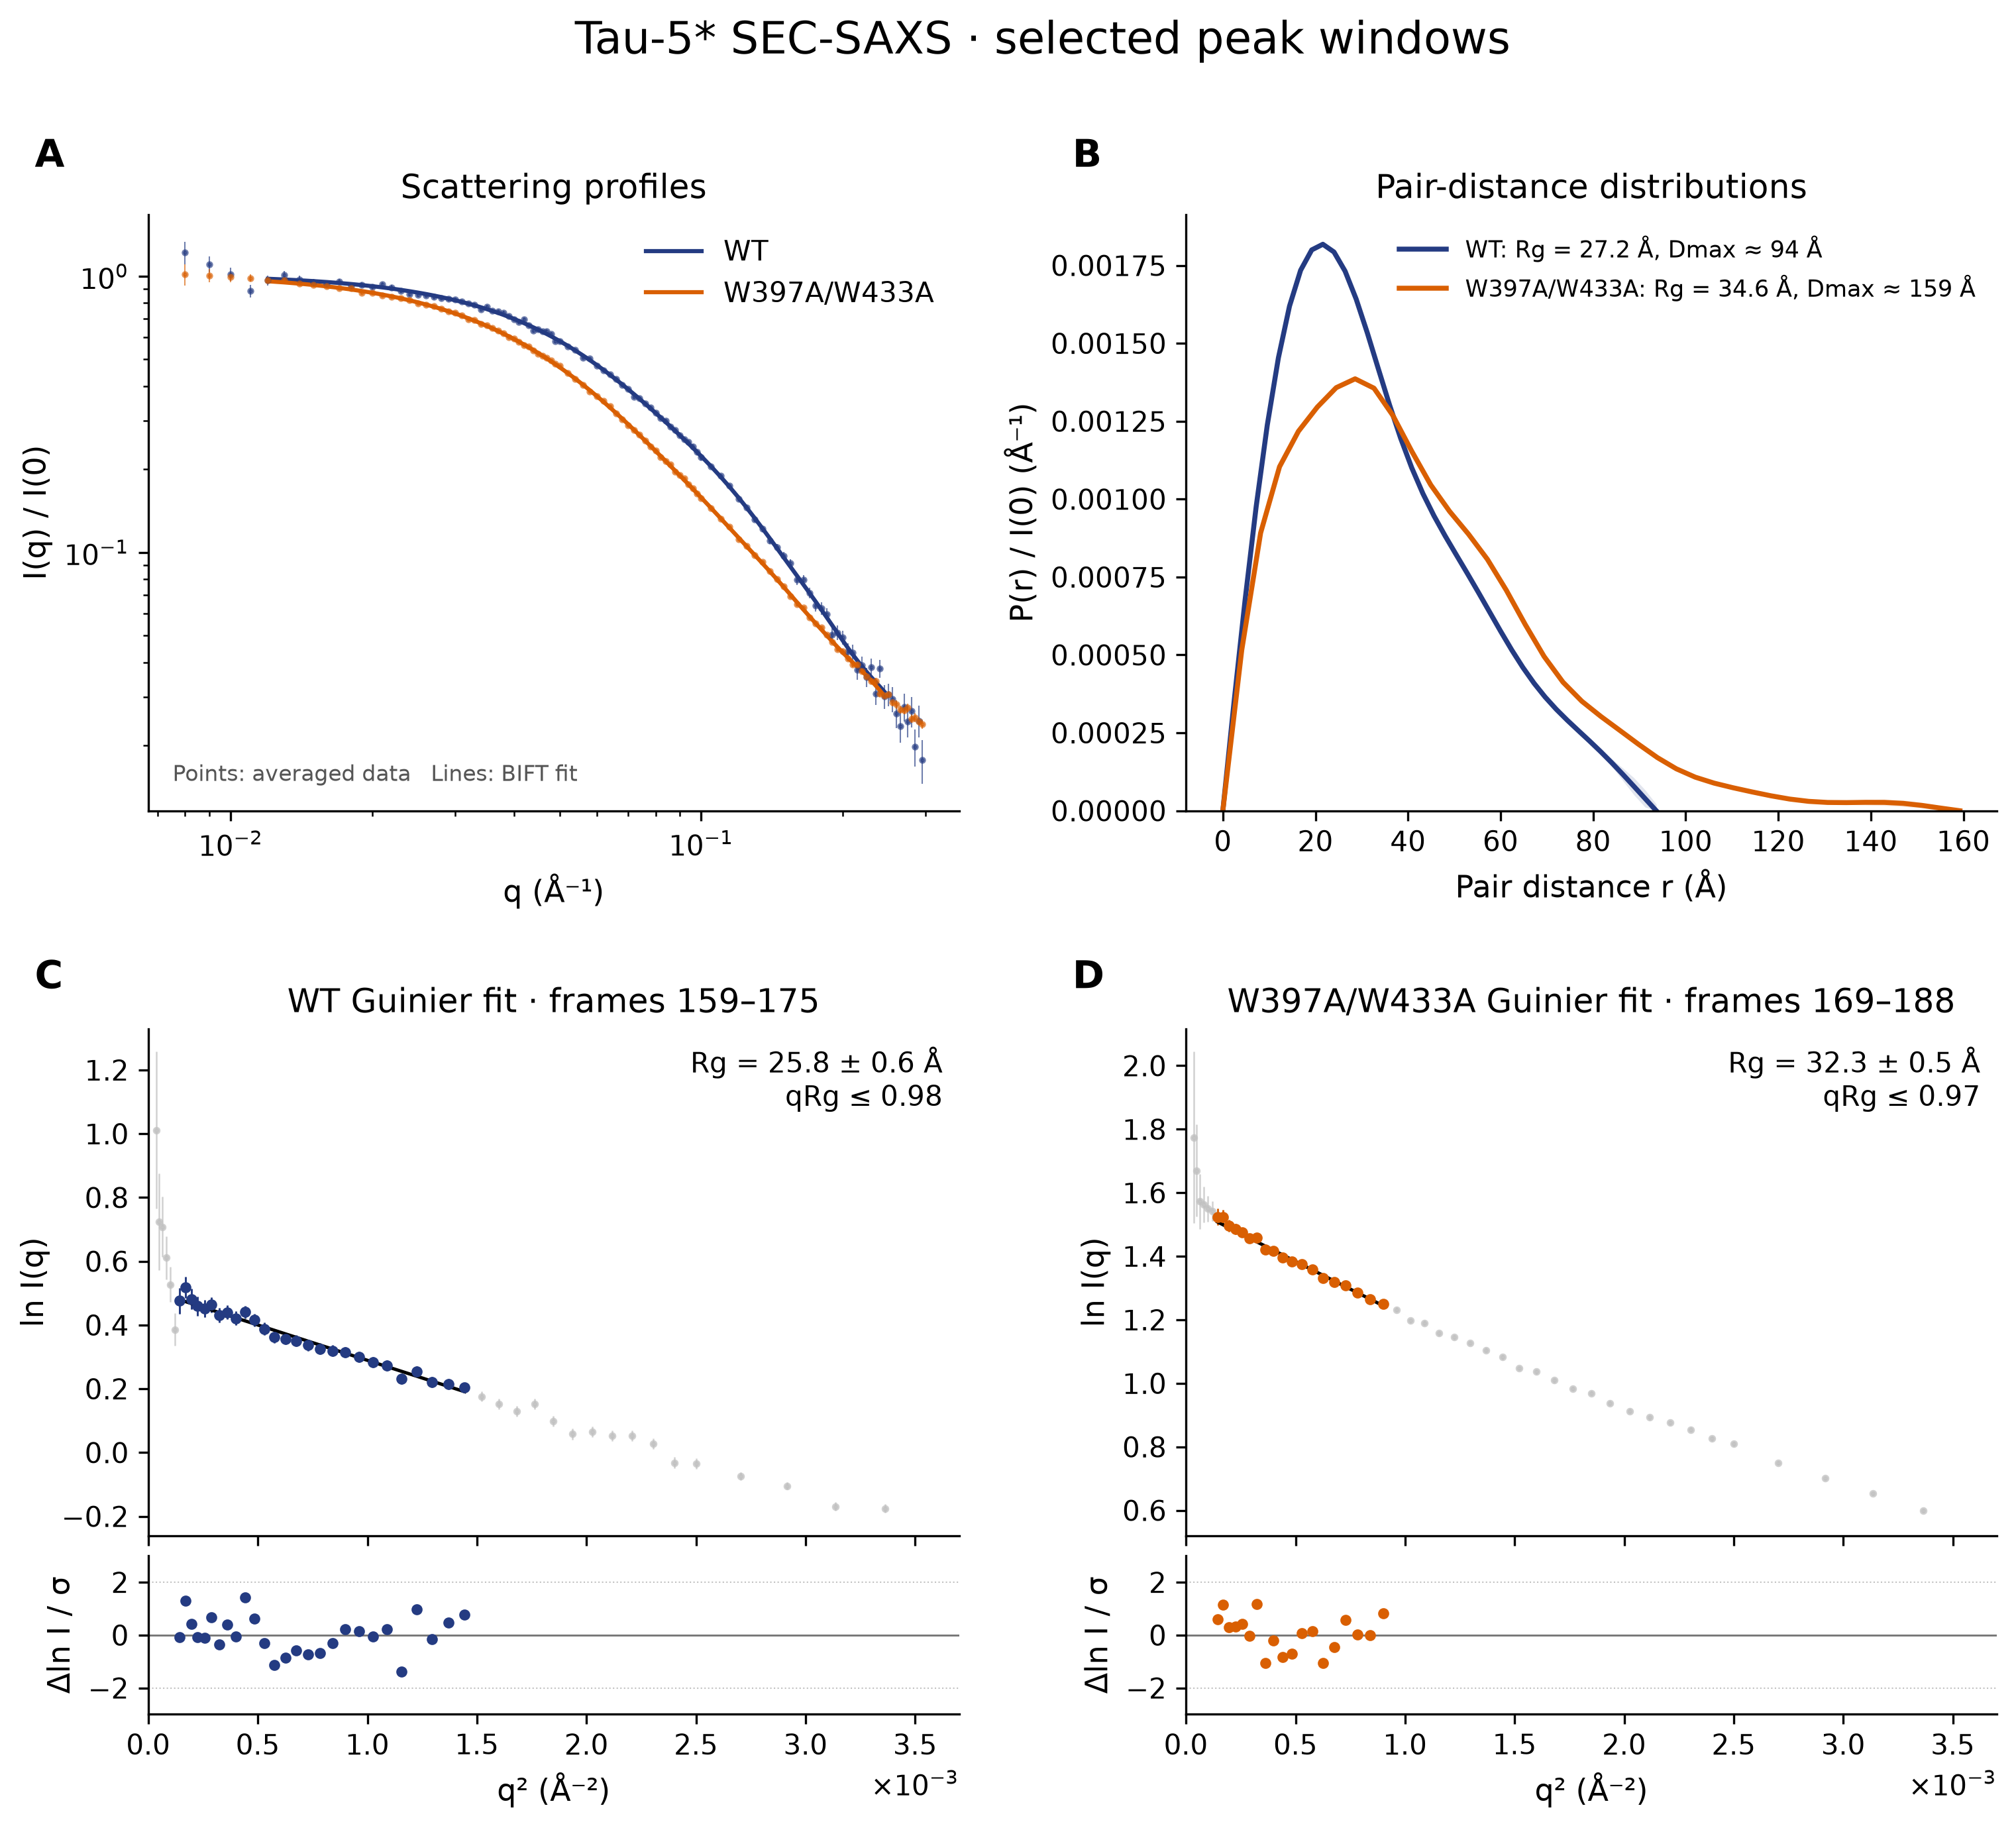

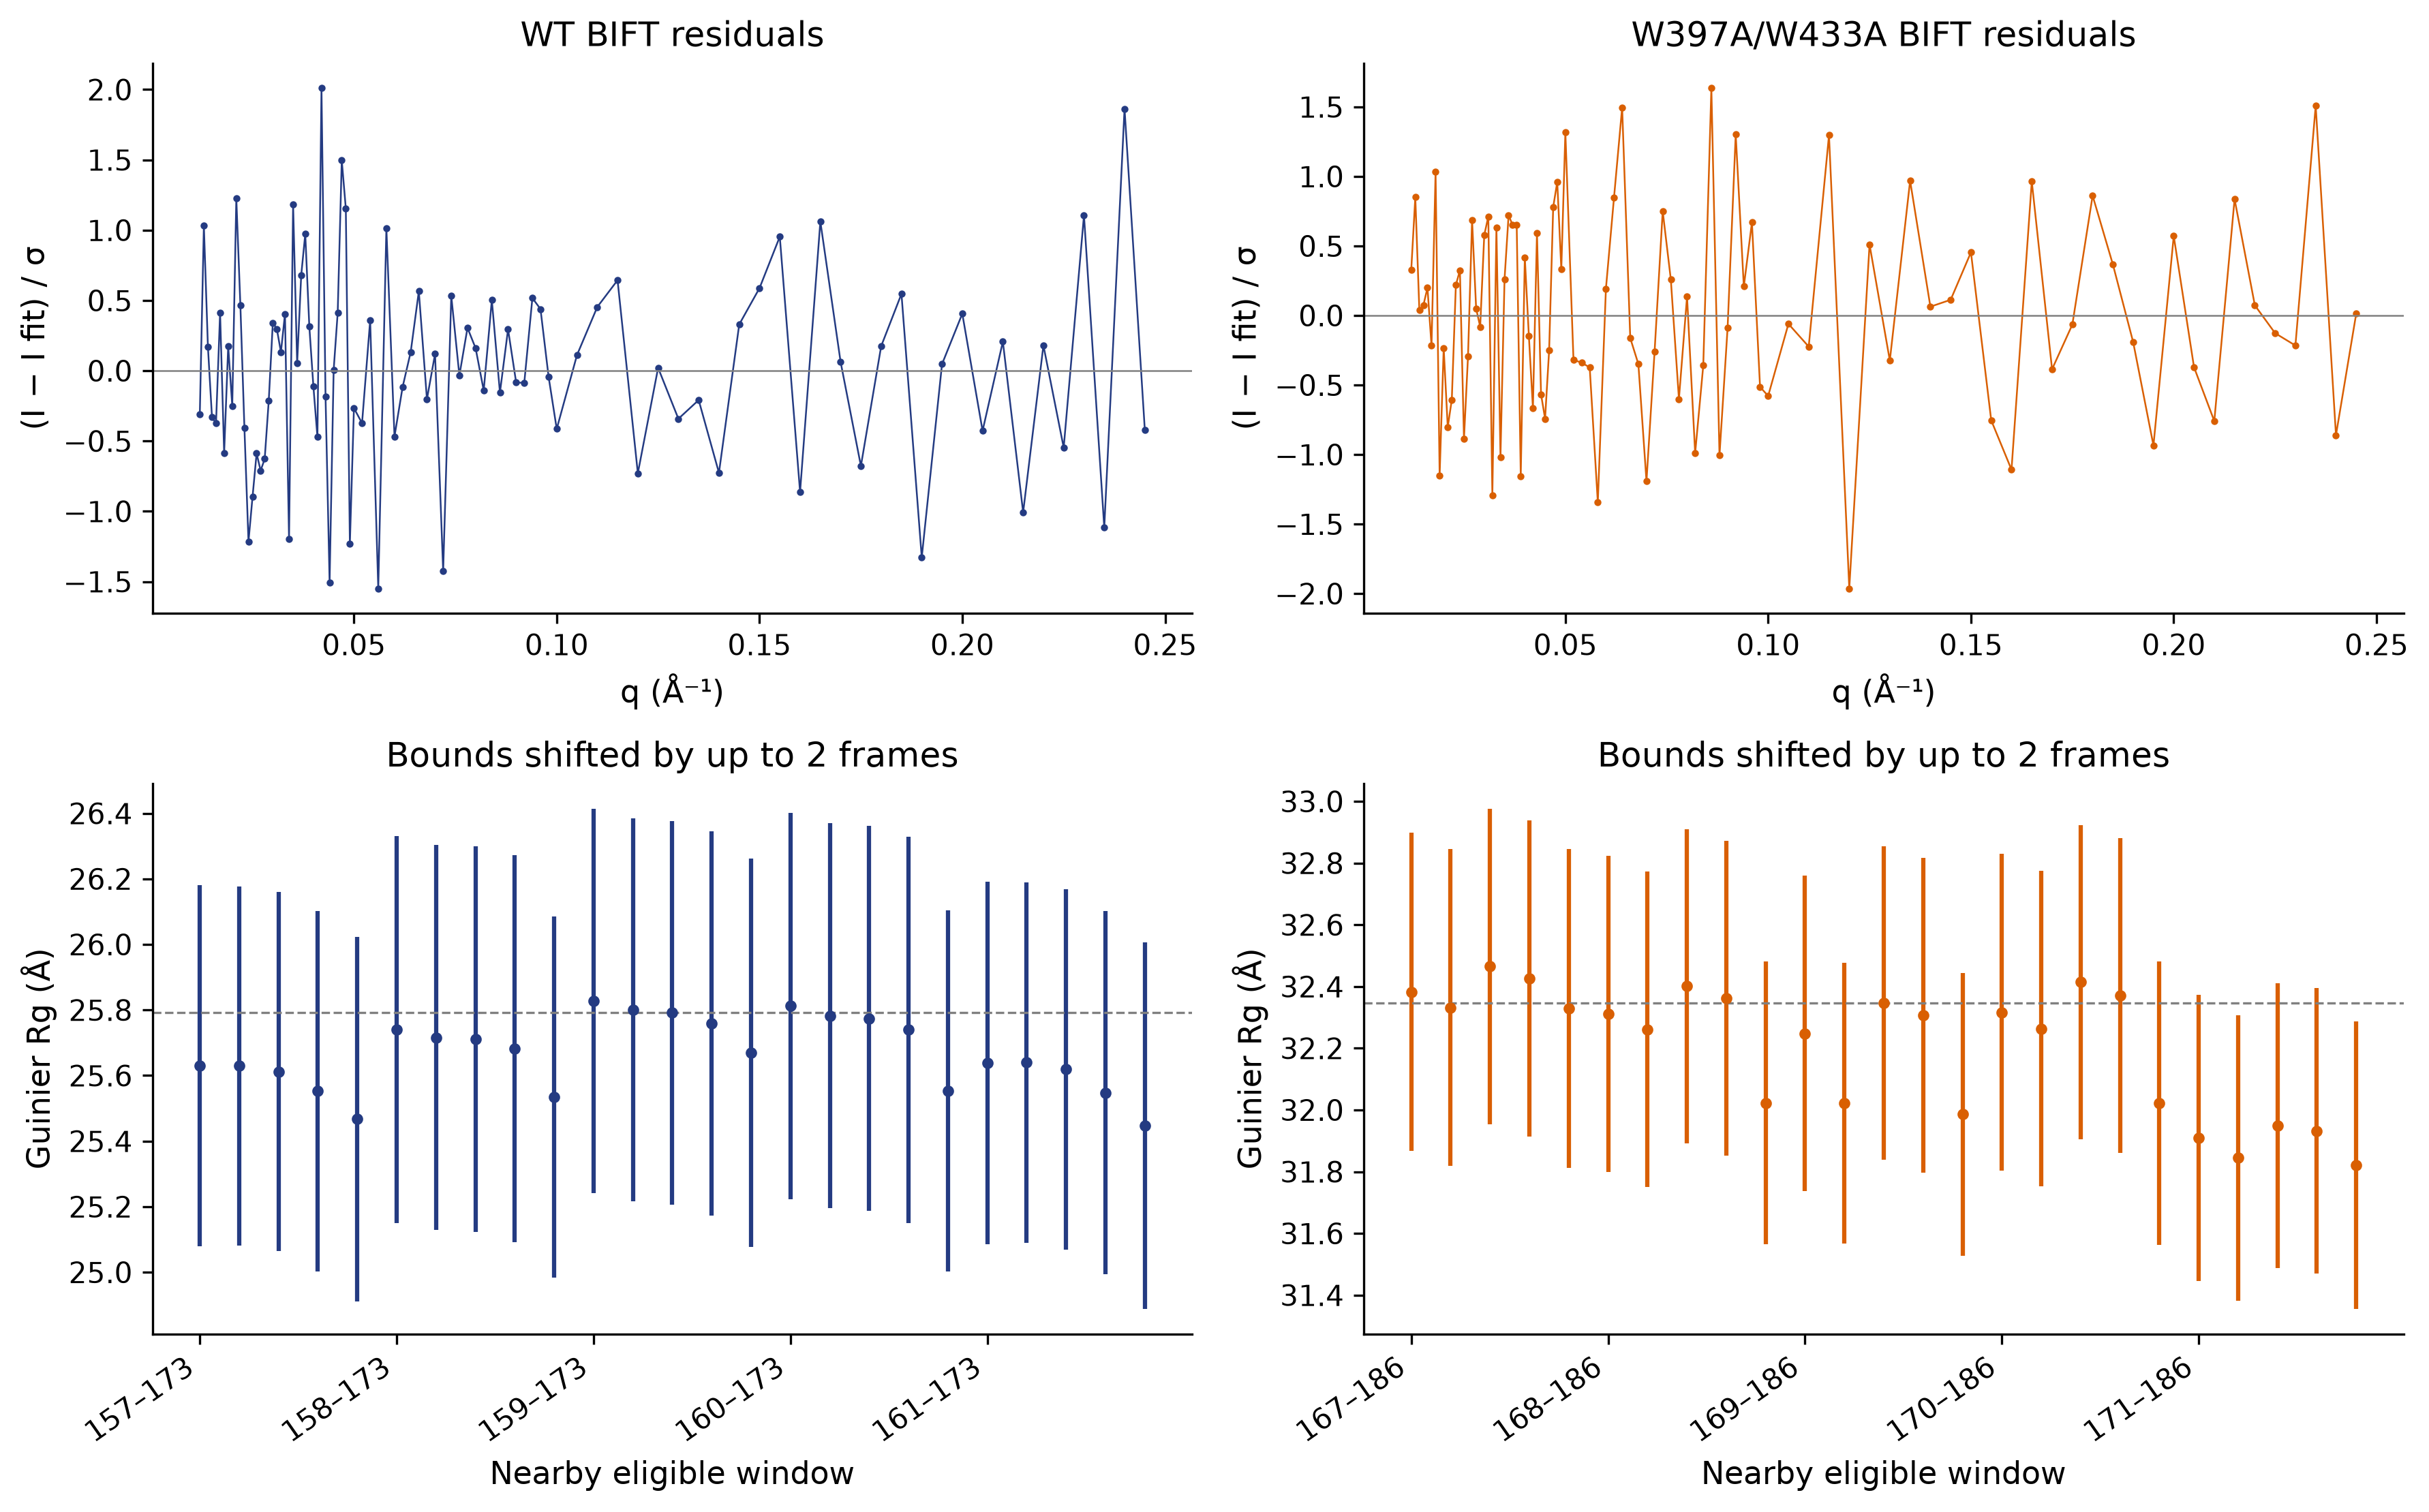

In [7]:
display(Image(filename=str(ROOT/'poster_results/poster_saxs_panel.png')))
display(Image(filename=str(ROOT/'poster_results/fit_and_window_diagnostics.png')))


## EFA: independent shape patterns across elution

We model the background-corrected matrix as $D=SC^T+E$, where S contains component scattering curves and C their elution amplitudes. Divide each q row by its mean error to obtain A, then calculate $A=U\Sigma V^T$. EFA repeats SVD on progressively longer leading and trailing frame blocks. Component time windows constrain a rotation toward nonnegative elution profiles; mathematical convergence alone does not prove physical separation.

The following recomputes the clean-region and shoulder-inclusive SVD tests. It does not force a second species into the clean regions.

In [8]:
efa_results = []
for name,a,b in [('WT_092025',155,180),('AA_052026',163,204),('WT_092025',125,195)]:
    r,_ = analyze(name,a,b,simulate=100)
    efa_results.append(r)
    print(name,(a,b),'s2 =',round(r['sv'][1],2),
          '99% rank-one null =',round(r['null_s2_99'],2),
          'q/time mode-2 smoothness =',round(r['q_ac'][1],2),round(r['t_ac'][1],2))


WT_092025 (155, 180) s2 = 13.48 99% rank-one null = 14.79 q/time mode-2 smoothness = 0.39 0.5


AA_052026 (163, 204) s2 = 13.86 99% rank-one null = 16.28 q/time mode-2 smoothness = 0.27 0.67
WT_092025 (125, 195) s2 = 49.62 99% rank-one null = 19.56 q/time mode-2 smoothness = 0.94 0.96


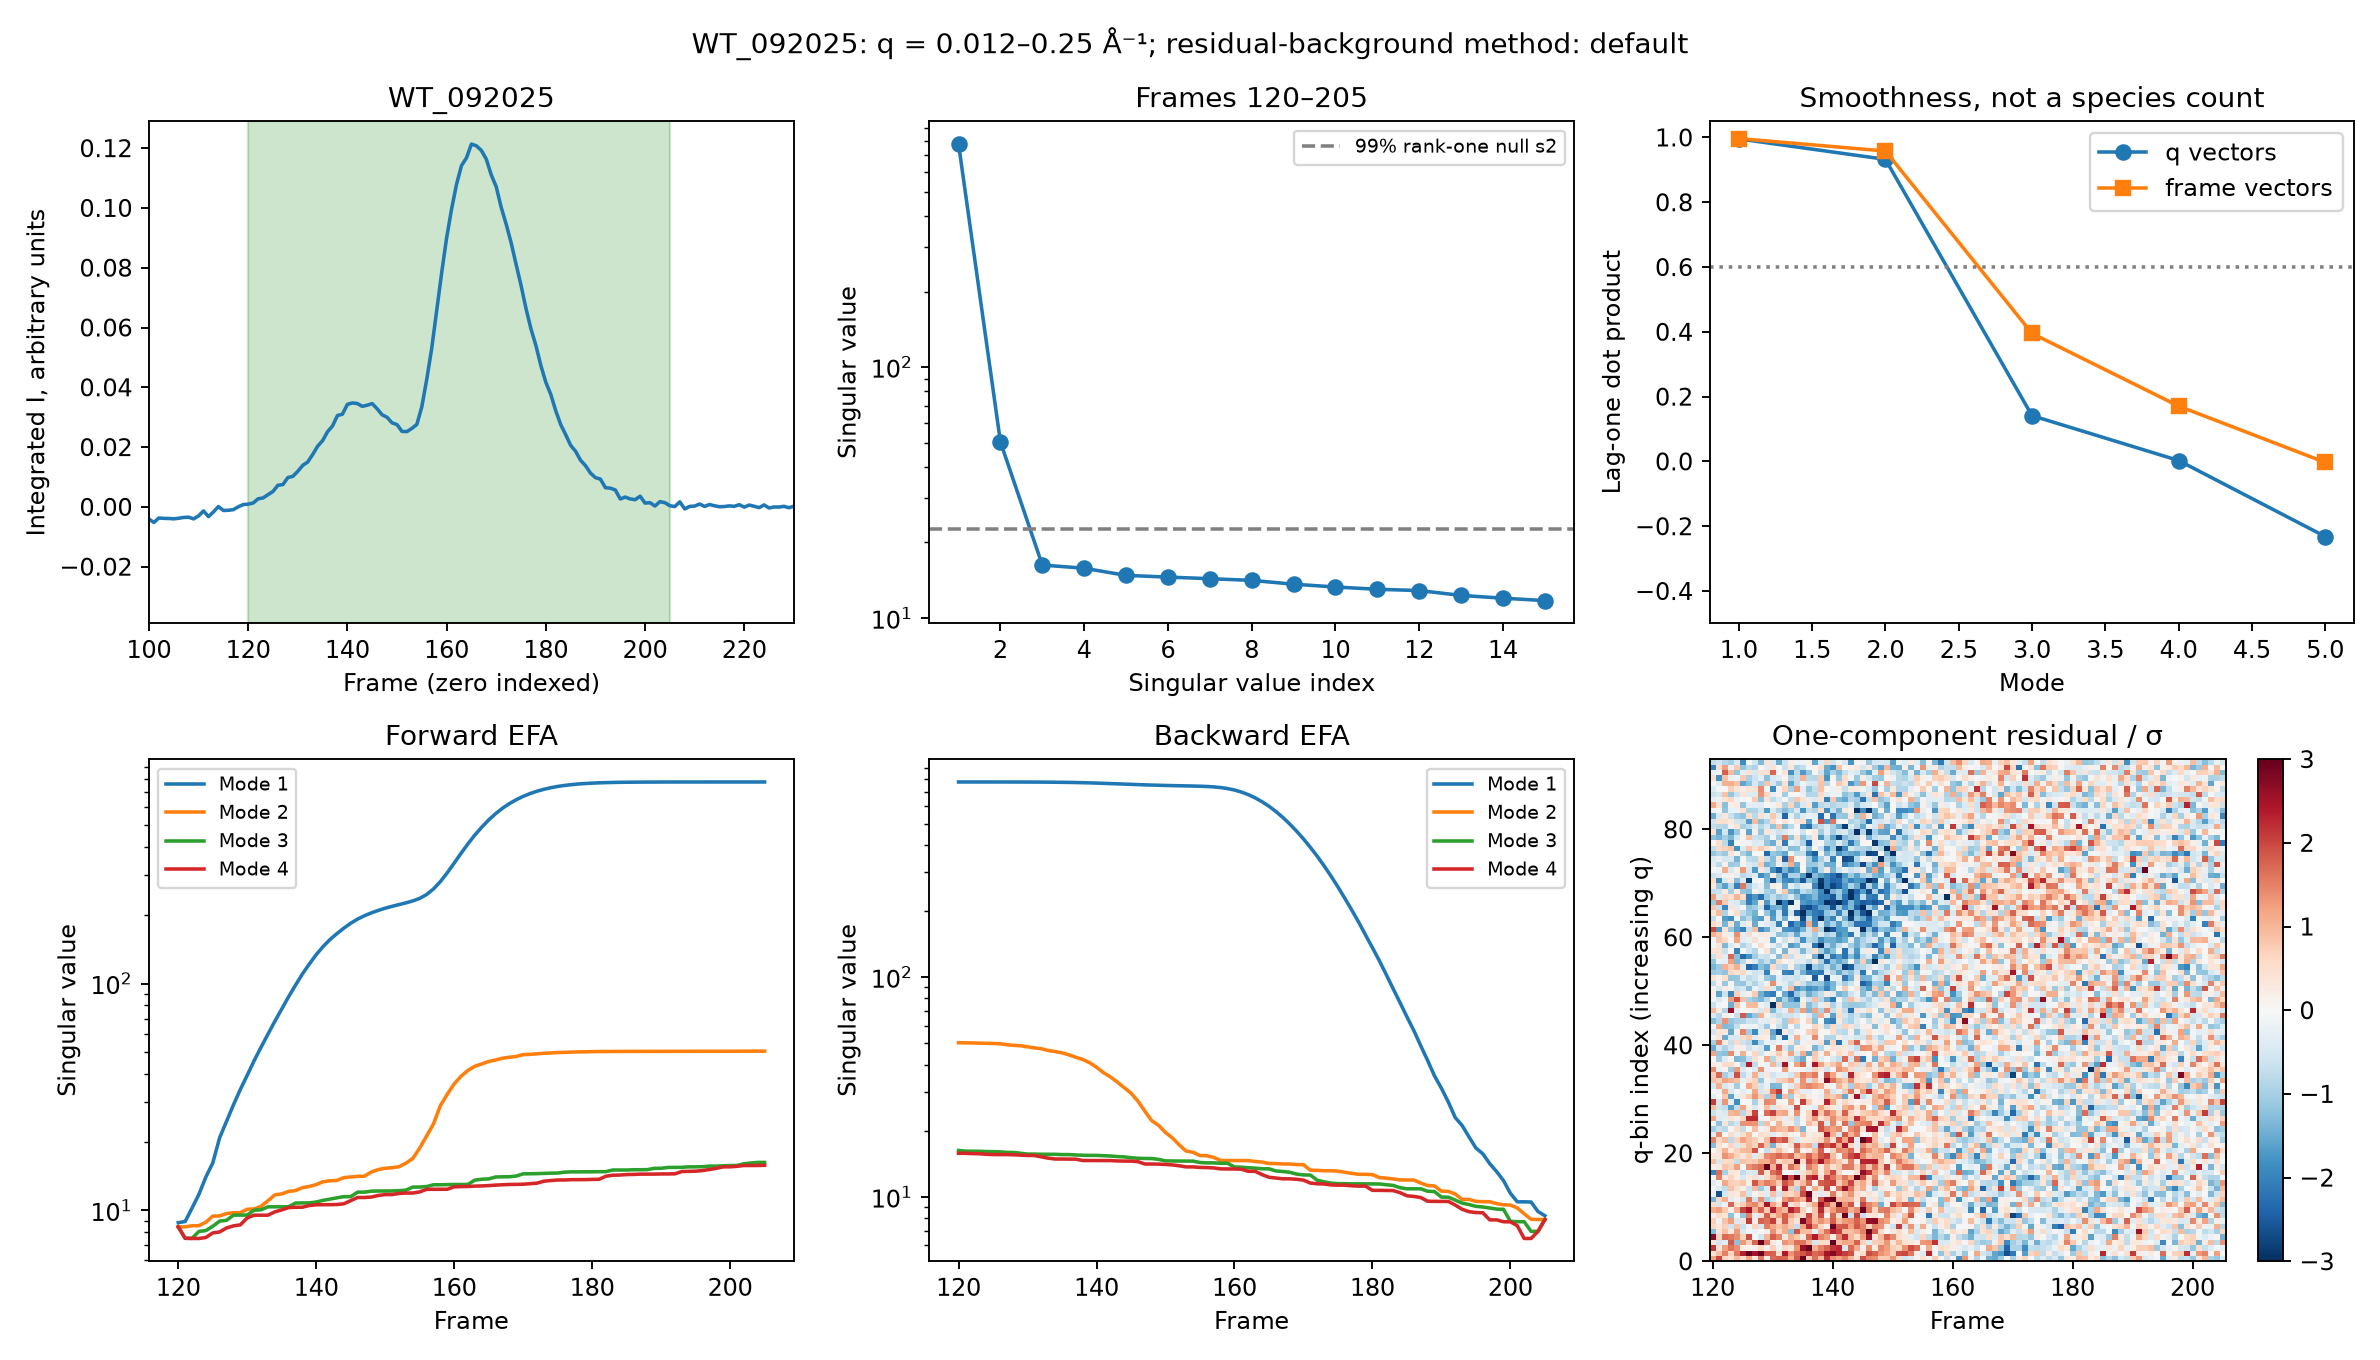

In [9]:
display(Image(filename=str(ROOT/'results/WT_092025_120-205_default_0.012-0.25_diagnostics.png')))


### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

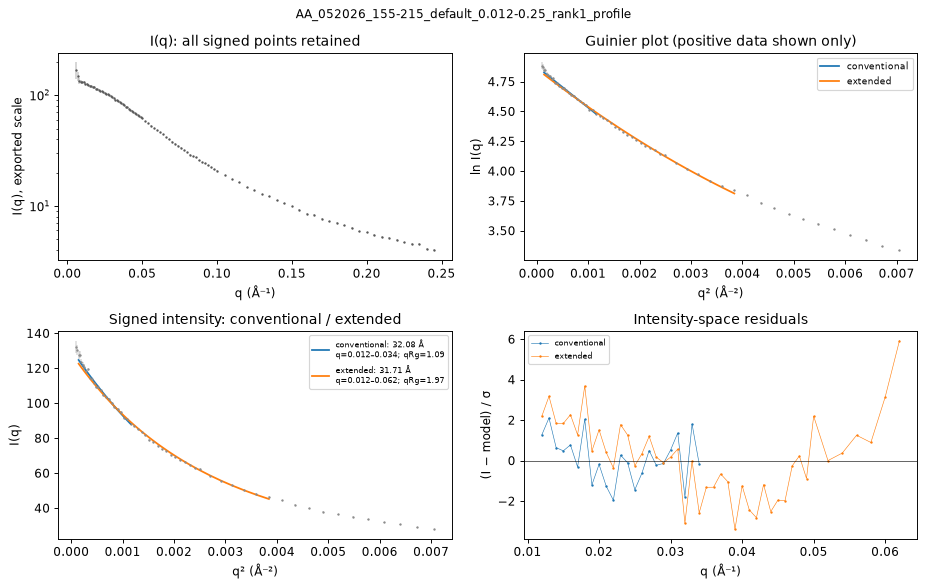

Extended residual chi-square/dof >2.

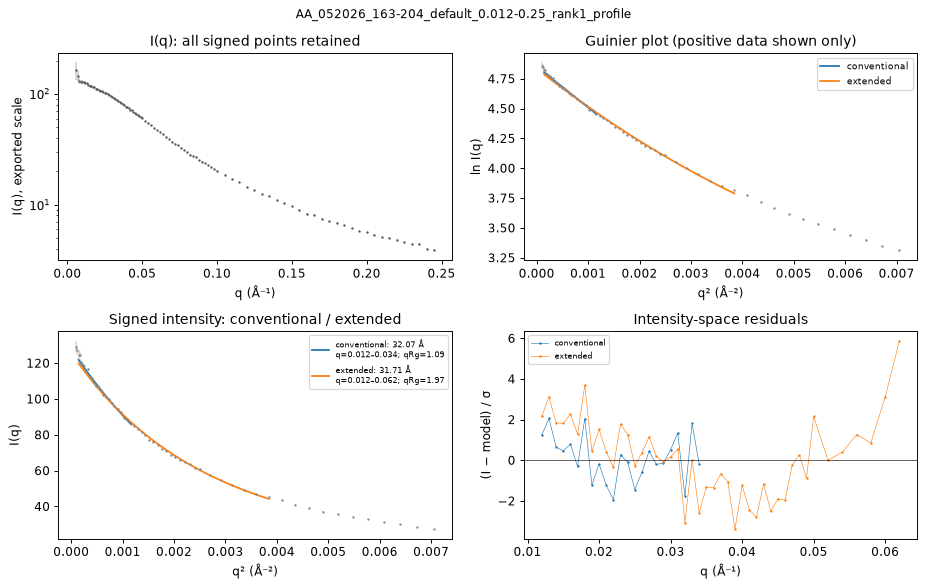

Extended residual chi-square/dof >2.

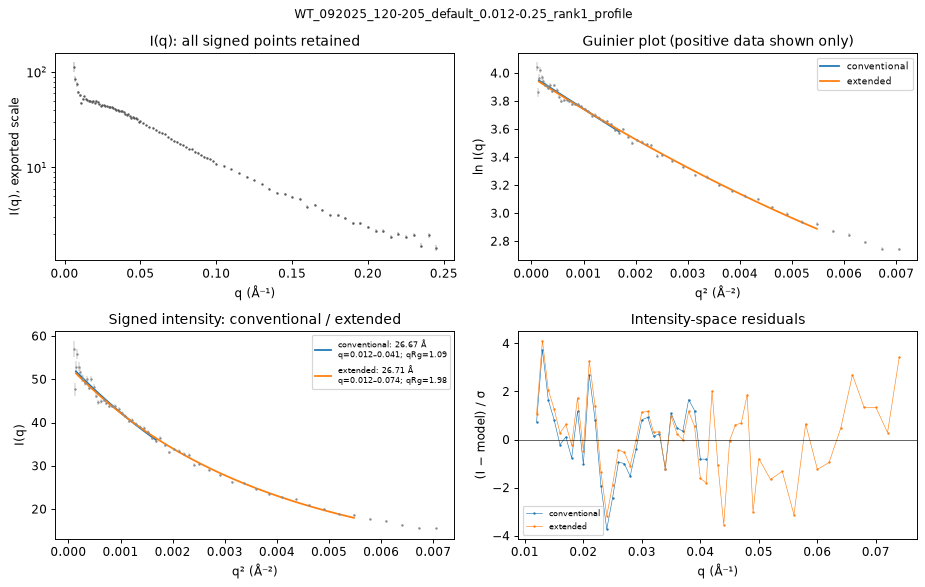

Conventional residual chi-square/dof >2. Extended residual chi-square/dof >2.

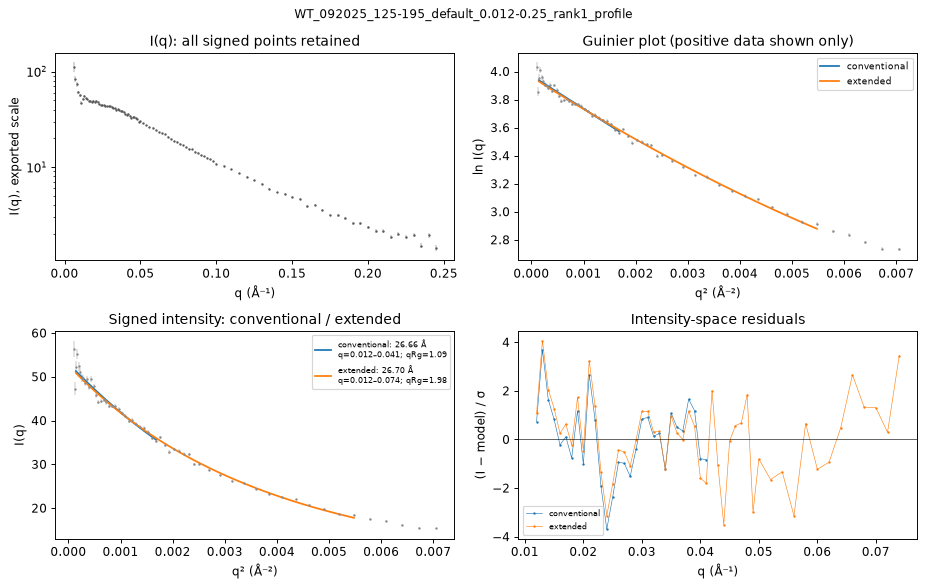

Conventional residual chi-square/dof >2. Extended residual chi-square/dof >2.

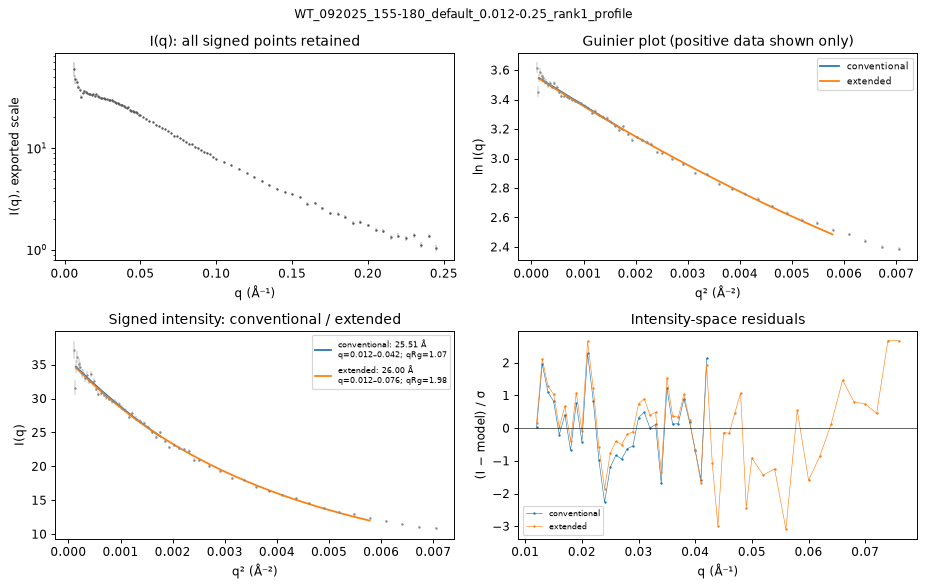

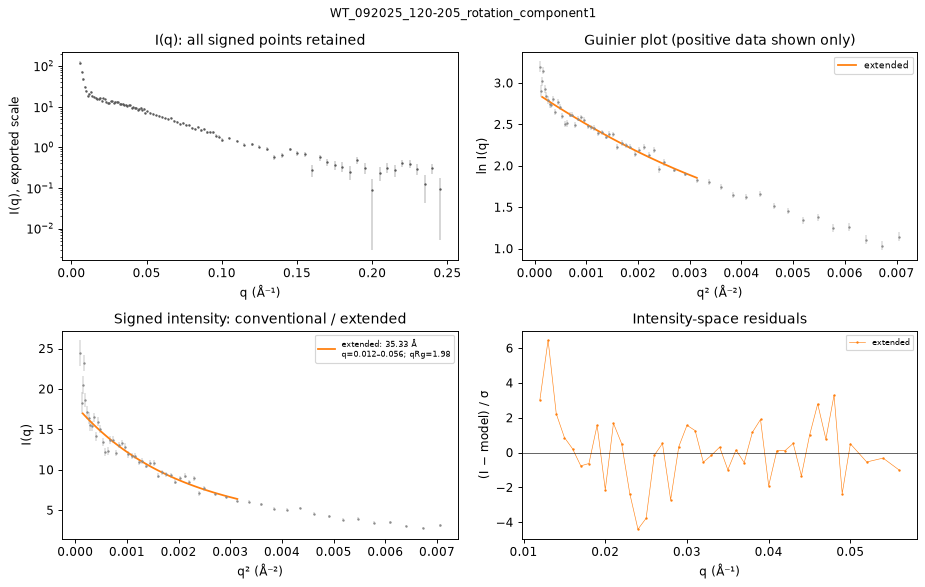

Component identity and physical validity are not established by a converged fit. Extended residual chi-square/dof >2.

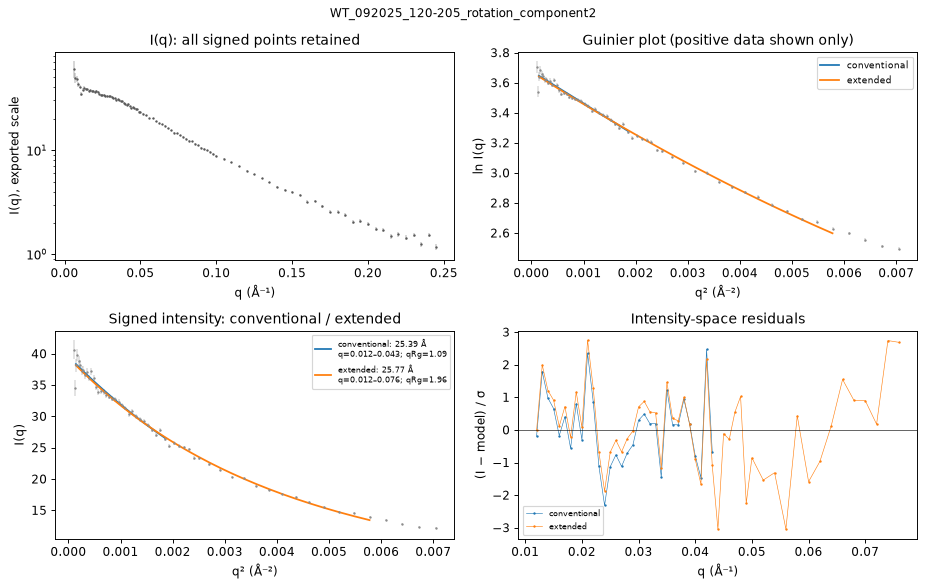

Component identity and physical validity are not established by a converged fit.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|AA_052026_155-215_default_0.012-0.25_rank1_profile|32.08 ± 0.24|33.44 ± 0.28|31.71 ± 0.07|[31.57, 31.85]|
|AA_052026_163-204_default_0.012-0.25_rank1_profile|32.07 ± 0.24|33.43 ± 0.28|31.71 ± 0.07|[31.57, 31.85]|
|WT_092025_120-205_default_0.012-0.25_rank1_profile|26.67 ± 0.29|27.50 ± 0.33|26.71 ± 0.10|[26.53, 26.9]|
|WT_092025_125-195_default_0.012-0.25_rank1_profile|26.66 ± 0.29|27.49 ± 0.33|26.70 ± 0.10|[26.53, 26.9]|
|WT_092025_155-180_default_0.012-0.25_rank1_profile|25.51 ± 0.31|26.28 ± 0.34|26.00 ± 0.10|[25.82, 26.2]|
|WT_092025_120-205_rotation_component1|unsupported|unsupported|35.33 ± 0.52|[34.35, 36.3]|
|WT_092025_120-205_rotation_component2|25.39 ± 0.29|26.18 ± 0.33|25.77 ± 0.10|[25.59, 25.96]|


In [2]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Legacy rank-one', 'Legacy EFA'])

## Interpretation and uncertainty

The clean peaks have one dominant scattering pattern. With the supplied errors, additional components are not robustly resolved. Scaling errors to smaller pre-peak empirical fluctuations makes weak clean-region second modes detectable, illustrating error-model sensitivity rather than establishing oligomers. WT has a clear additional pattern when the earlier shoulder is included, but its recovered low-q shape and component-window dependence prevent a reliable oligomer/Rg assignment.

The selected-window plot values differ slightly from the broader clean-region EFA profile values because these are direct arithmetic averages over optimized windows, with shared-background uncertainty retained. Guinier and P(r) Rg values are intentionally reported separately. Nearby q/window sensitivity is small for BIFT, but background choice remains a material systematic, particularly for WT.

Read `poster_results/README.md` for the figure caption and exact parameters. The full EFA derivation is in `EFA_equations.md`.

In [10]:
print((ROOT/'results/noise_scale_sensitivity.json').read_text())
print((ROOT/'results/provenance.json').read_text())


[
  {
    "sample": "WT_092025",
    "assumed_noise_multiplier": 0.8291275434553121,
    "observed_s2": 13.483991518163284,
    "null_s2_99": 12.345679174351577,
    "p_rank1": 0.0033222591362126247,
    "interpretation": "Exploratory: noise calibrated from pre-peak frames may not transfer to protein peak or account for correlations."
  },
  {
    "sample": "AA_052026",
    "assumed_noise_multiplier": 0.7350958027662233,
    "observed_s2": 13.862660876208073,
    "null_s2_99": 12.018581639540999,
    "p_rank1": 0.0033222591362126247,
    "interpretation": "Exploratory: noise calibrated from pre-peak frames may not transfer to protein peak or account for correlations."
  }
]
{
  "input_repository": "https://github.com/Natalie-Loui/BNL_SAXS",
  "input_commit": "4a6ac1c514d25a589e671a91efd1f38c4bcb316c",
  "raw_repository": "https://github.com/jbhopkins/bioxtasraw",
  "raw_commit": "90f86f96cdc907d0bd41d3ba96d4936a9b1b0e2a",
  "python": "3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3